# CellTypist 参考标签

公开免疫参考集给每个细胞一个「最像谁」的标签，给 04 人工命名当线索。不是颅骨骨髓金标准。骨髓中性粒常被标成单核，以 04 / 05 的 marker 为准。


In [1]:
import time

import numpy as np
import scanpy as sc
from session_info2 import session_info

import celltypist
from celltypist import models

/home/han/software/miniconda3/envs/celltypist/lib/python3.12/site-packages/celltypist/classifier.py:11: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  from scanpy import __version__ as scv


## 1. Download Reference

下载公开免疫参考模型。


In [2]:
# models.download_models(force_update=True)

In [3]:
model_high = models.Model.load(model="Immune_All_High.pkl")
model_low = models.Model.load(model="Immune_All_Low.pkl")

In [4]:
model_high.cell_types

array(['B cells', 'B-cell lineage', 'Cycling cells', 'DC', 'DC precursor',
       'Double-negative thymocytes', 'Double-positive thymocytes', 'ETP',
       'Early MK', 'Endothelial cells', 'Epithelial cells',
       'Erythrocytes', 'Erythroid', 'Fibroblasts', 'Granulocytes',
       'HSC/MPP', 'ILC', 'ILC precursor', 'MNP', 'Macrophages',
       'Mast cells', 'Megakaryocyte precursor',
       'Megakaryocytes/platelets', 'Mono-mac', 'Monocyte precursor',
       'Monocytes', 'Myelocytes', 'Plasma cells', 'Promyelocytes',
       'T cells', 'pDC', 'pDC precursor'], dtype=object)

In [5]:
model_low.cell_types

array(['Age-associated B cells', 'Alveolar macrophages', 'B cells',
       'CD16+ NK cells', 'CD16- NK cells', 'CD8a/a', 'CD8a/b(entry)',
       'CMP', 'CRTAM+ gamma-delta T cells', 'Classical monocytes',
       'Cycling B cells', 'Cycling DCs', 'Cycling NK cells',
       'Cycling T cells', 'Cycling gamma-delta T cells',
       'Cycling monocytes', 'DC', 'DC precursor', 'DC1', 'DC2', 'DC3',
       'Double-negative thymocytes', 'Double-positive thymocytes', 'ELP',
       'ETP', 'Early MK', 'Early erythroid', 'Early lymphoid/T lymphoid',
       'Endothelial cells', 'Epithelial cells', 'Erythrocytes',
       'Erythrophagocytic macrophages', 'Fibroblasts',
       'Follicular B cells', 'Follicular helper T cells', 'GMP',
       'Germinal center B cells', 'Granulocytes', 'HSC/MPP',
       'Hofbauer cells', 'ILC', 'ILC precursor', 'ILC1', 'ILC2', 'ILC3',
       'Intermediate macrophages', 'Intestinal macrophages',
       'Kidney-resident macrophages', 'Kupffer cells',
       'Large pre-B cell

## 2. Load Data and Check Normalization

读入上一篇导出的 h5ad，确认已经是归一化表达。


In [6]:
adata = sc.read("../celltypist/seurat_object.h5ad")
adata.obsm["X_umap"] = np.asarray(adata.obsm["UMAP_HARMONY"])

In [7]:
adata.X[1000:1010, 500:510].toarray()

array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [2., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 3., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.]])

In [8]:
adata.X.sum(axis=1)

matrix([[6292.],
        [ 999.],
        [2523.],
        ...,
        [ 696.],
        [6616.],
        [6425.]], shape=(148682, 1))

In [9]:
adata.X.expm1().sum(axis=1)

matrix([[1.27089863e+062],
        [3.58504247e+009],
        [6.07603023e+037],
        ...,
        [2.90489192e+013],
        [3.61033306e+161],
        [1.47285655e+121]], shape=(148682, 1))

In [10]:
sc.pp.normalize_total(adata, target_sum=1e4)

In [11]:
adata.X.sum(axis=1)

matrix([[10000.],
        [10000.],
        [10000.],
        ...,
        [10000.],
        [10000.],
        [10000.]], shape=(148682, 1))

In [12]:
adata.X.expm1().sum(axis=1)

matrix([[5.04999958e+098],
        [4.36944669e+095],
        [5.71107545e+149],
        ...,
        [2.72747399e+193],
        [1.55661597e+244],
        [3.87772117e+188]], shape=(148682, 1))

In [13]:
sc.pp.log1p(adata)

## 3. Prediction

给每个细胞一个参考标签和置信度。置信度低的不要单独拿去写机制。


In [14]:
t_start = time.time()
predictions_low = celltypist.annotate(
    adata, model="Immune_All_Low.pkl", majority_voting=True
)
t_end = time.time()
print(f"Time elapsed: {t_end - t_start} seconds")

🔬 Input data has 148682 cells and 38606 genes
🔗 Matching reference genes in the model
🧬 5824 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!
👀 Can not detect a neighborhood graph, will construct one before the over-clustering
/home/han/software/miniconda3/envs/celltypist/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
⛓️ Over-clustering input data with resolution set to 25
🗳️ Majority voting the predictions
✅ Majority voting done!


Time elapsed: 216.93211460113525 seconds


In [15]:
predictions_low = predictions_low.to_adata()
predictions_low

AnnData object with n_obs × n_vars = 148682 × 38606
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'group', 'sample', 'percent_mt', 'percent_rb', 'percent_hb', 'percent_pt', 's_score', 'g2m_score', 'phase', 'cc_diff', 'is_doublet', 'doublet_score', 'harmony_clusters_0.01', 'harmony_clusters_0.05', 'harmony_clusters_0.1', 'harmony_clusters_0.2', 'harmony_clusters_0.5', 'harmony_clusters_1', 'ident', 'predicted_labels', 'over_clustering', 'majority_voting', 'conf_score'
    uns: 'X_name', 'log1p', 'neighbors', 'over_clustering'
    obsm: 'HARMONY', 'PCA', 'UMAP_HARMONY', 'UMAP_UNINT', 'X_umap', 'X_pca'
    obsp: 'connectivities', 'distances'
    layers: None (.X)

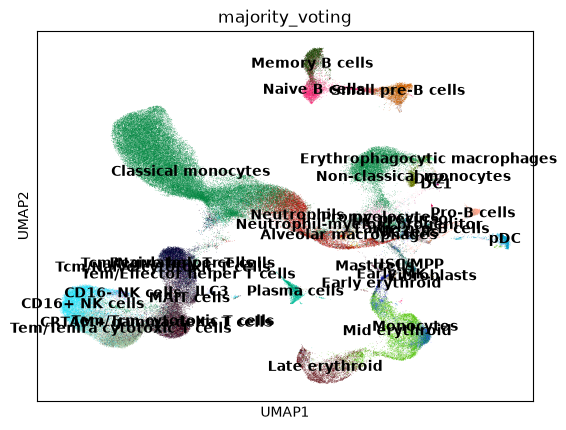

In [16]:
sc.pl.umap(
    predictions_low, color=["majority_voting"], legend_loc="on data", size=1, alpha=.5,
)

In [17]:
t_start = time.time()
predictions_high = celltypist.annotate(
    adata, model="Immune_All_High.pkl", majority_voting=True
)
t_end = time.time()
print(f"Time elapsed: {t_end - t_start} seconds")

🔬 Input data has 148682 cells and 38606 genes
🔗 Matching reference genes in the model
🧬 5824 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!
👀 Detected a neighborhood graph in the input object, will run over-clustering on the basis of it
⛓️ Over-clustering input data with resolution set to 25
🗳️ Majority voting the predictions
✅ Majority voting done!


Time elapsed: 10.706525087356567 seconds


In [18]:
predictions_high = predictions_high.to_adata()
predictions_high

AnnData object with n_obs × n_vars = 148682 × 38606
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'group', 'sample', 'percent_mt', 'percent_rb', 'percent_hb', 'percent_pt', 's_score', 'g2m_score', 'phase', 'cc_diff', 'is_doublet', 'doublet_score', 'harmony_clusters_0.01', 'harmony_clusters_0.05', 'harmony_clusters_0.1', 'harmony_clusters_0.2', 'harmony_clusters_0.5', 'harmony_clusters_1', 'ident', 'predicted_labels', 'majority_voting', 'conf_score', 'over_clustering'
    uns: 'X_name', 'log1p', 'neighbors', 'over_clustering', 'majority_voting_colors'
    obsm: 'HARMONY', 'PCA', 'UMAP_HARMONY', 'UMAP_UNINT', 'X_umap', 'X_pca'
    obsp: 'connectivities', 'distances'
    layers: None (.X)

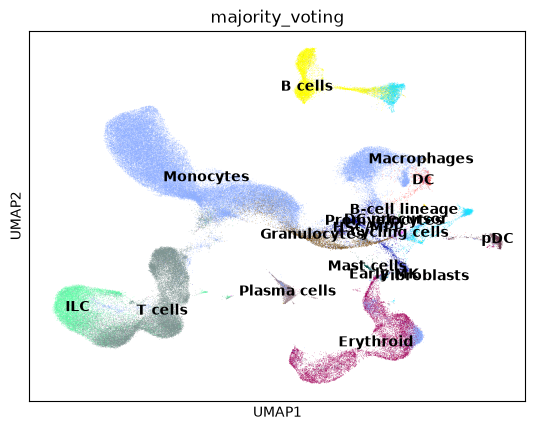

In [19]:
sc.pl.umap(
    predictions_high,
    color=["majority_voting"],
    legend_loc="on data",
    size=1,
    alpha=0.5,
)

## 4. Save Results

把标签写回，供 04 对照。


In [20]:
predictions_low.obs.loc[
    :, ["predicted_labels", "over_clustering", "majority_voting", "conf_score"]
].to_csv("../celltypist/predictions_low.tsv", sep="\t")

predictions_high.obs.loc[
    :, ["predicted_labels", "over_clustering", "majority_voting", "conf_score"]
].to_csv("../celltypist/predictions_high.tsv", sep="\t")

In [21]:
print(session_info())

anndata	0.13.3.post0
numpy	2.5.3
scanpy	1.12.4
celltypist	1.7.1
----	----
Python	3.12.14 (main, Sep  2 2026, 23:27:36) [GCC 15.3.0]
OS	Linux-6.17.0-22-generic-x86_64-with-glibc2.39
Updated	2026-09-14 09:26
